# WheelWise a Bike Rental Demand Predictor

This project predicts the number of bicycles likely to be rented during one operating hour in Seoul.

The prediction target is **Rented Bike Count**, which is a numerical value. Therefore, this is a **regression problem**.

## 1. Import libraries and set project options

This section imports all Python libraries needed for data handling, visualisation, machine learning, evaluation, and saving the trained model. A fixed random state is used so the results can be reproduced.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")                                      # Hides unnecessary warning messages.
RANDOM_STATE = 42                                                       # Keeps the results consistent each time.
DATA_PATH = Path("SeoulBikeData.csv")                                   # Points to the dataset in this folder.
sns.set_theme(style="whitegrid")                                       # Gives all charts a clean and similar style.

## 2. Data collection and inspection

The original dataset contains 8,760 hourly observations and 14 columns, which is more than the required minimum of 500 rows and 8 columns. This section loads the CSV file, checks the size, previews the records, and inspects data types, missing values, and unique values.

In [2]:
try:
    raw_df = pd.read_csv(DATA_PATH, encoding="utf-8")                   # Tries the standard file encoding first.
except UnicodeDecodeError:
    raw_df = pd.read_csv(DATA_PATH, encoding="latin1")                  # Uses another encoding if special symbols fail.

print("Dataset shape:", raw_df.shape)                                   # Shows the total number of rows and columns.
display(raw_df.head())                                                  # Displays the first five records for inspection.

inspection_table = pd.DataFrame({
    "Data Type": raw_df.dtypes.astype(str),                             # Shows how each column is stored.
    "Missing Values": raw_df.isna().sum(),                              # Counts empty values in each column.
    "Unique Values": raw_df.nunique(),                                  # Shows how many different values each column has.
})
display(inspection_table)                                               # Presents the inspection results in one table.

Dataset shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


,Data Type,Missing Values,Unique Values
Date,object,0,365
Rented Bike Count,int64,0,2166
Hour,int64,0,24
Temperature(°C),float64,0,546
Humidity(%),int64,0,90
Wind speed (m/s),float64,0,65
Visibility (10m),int64,0,1789
Dew point temperature(°C),float64,0,556
Solar Radiation (MJ/m2),float64,0,345
Rainfall(mm),float64,0,61


## 3. Data cleaning and preparation

This section prepares the dataset for reliable analysis. It removes duplicate rows, converts the date column into a proper date format, gives columns simpler names, checks missing values, and removes non-functioning periods because they represent service shutdown rather than real customer demand.

In [3]:
df = raw_df.copy()                                                       # Creates a working copy and protects the original data.

duplicate_count = df.duplicated().sum()                                 # Counts fully repeated rows.
df = df.drop_duplicates().copy()                                       # Removes repeated rows from the dataset.

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce",
)                                                                       # Converts the Date column from text into datetime format.

rename_map = {
    "Rented Bike Count": "rented_bike_count",
    "Hour": "hour",
    "Temperature(°C)": "temperature_c",
    "Humidity(%)": "humidity_pct",
    "Wind speed (m/s)": "wind_speed_ms",
    "Visibility (10m)": "visibility_10m",
    "Dew point temperature(°C)": "dew_point_c",
    "Solar Radiation (MJ/m2)": "solar_radiation",
    "Rainfall(mm)": "rainfall_mm",
    "Snowfall (cm)": "snowfall_cm",
    "Seasons": "season",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day",
}
df = df.rename(columns=rename_map)                                      # Makes all column names easier to use in Python.

shutdown_rows = (df["functioning_day"] != "Yes").sum()                  # Counts hours when the service was not operating.
df = df[df["functioning_day"] == "Yes"].copy()                          # Keeps only normal operating hours.

print("Duplicate rows removed:", duplicate_count)                       # Reports how many duplicate rows were deleted.
print("Non-functioning rows removed:", shutdown_rows)                   # Reports how many shutdown rows were removed.
print("Cleaned dataset shape:", df.shape)                               # Shows the remaining size after cleaning.
display(df.isna().sum().to_frame("Missing Values"))                     # Confirms whether any missing values remain.

Duplicate rows removed: 0
Non-functioning rows removed: 295
Cleaned dataset shape: (8465, 14)


,Missing Values
Date,0
rented_bike_count,0
hour,0
temperature_c,0
humidity_pct,0
wind_speed_ms,0
visibility_10m,0
dew_point_c,0
solar_radiation,0
rainfall_mm,0


## 4. Outlier checking

Outliers are unusually low or high values. The Interquartile Range method is used to identify possible outliers in important numerical columns. Genuine extreme demand and weather values are kept because they may represent real busy hours or unusual weather conditions.

In [4]:
def create_iqr_summary(data, columns):
    rows = []                                                            # Stores one outlier summary for each column.

    for column in columns:
        q1 = data[column].quantile(0.25)                                 # Finds the lower quartile.
        q3 = data[column].quantile(0.75)                                 # Finds the upper quartile.
        iqr = q3 - q1                                                    # Measures the middle spread of the data.
        lower_limit = q1 - (1.5 * iqr)                                  # Calculates the lower outlier boundary.
        upper_limit = q3 + (1.5 * iqr)                                  # Calculates the upper outlier boundary.

        outlier_count = (
            (data[column] < lower_limit) |
            (data[column] > upper_limit)
        ).sum()                                                          # Counts values outside both boundaries.

        rows.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "Lower Limit": lower_limit,
            "Upper Limit": upper_limit,
            "Possible Outliers": outlier_count,
        })                                                               # Adds the result for the current feature.

    return pd.DataFrame(rows)                                            # Returns all outlier results as a table.

outlier_columns = [
    "rented_bike_count",
    "temperature_c",
    "humidity_pct",
    "solar_radiation",
    "rainfall_mm",
]

outlier_summary = create_iqr_summary(df, outlier_columns)                # Runs the IQR check on key numerical variables.
display(outlier_summary.round(2))                                       # Shows the outlier boundaries and counts.

,Feature,Q1,Q3,Lower Limit,Upper Limit,Possible Outliers
0,rented_bike_count,214.0,1084.00,-1091.00,2389.00,152
1,temperature_c,3.0,22.70,-26.55,52.25,0
2,humidity_pct,42.0,74.00,-6.00,122.00,0
3,solar_radiation,0.0,0.93,-1.40,2.33,620
4,rainfall_mm,0.0,0.00,0.00,0.00,516


## 5. Descriptive statistics

Descriptive statistics summarise the main numerical features. The table includes minimum, maximum, mean, median, standard deviation, quartiles, and skewness. These values help explain the typical demand level and the overall spread of the data.

In [5]:
key_numeric = [
    "rented_bike_count",
    "hour",
    "temperature_c",
    "humidity_pct",
    "solar_radiation",
    "rainfall_mm",
]

statistics = df[key_numeric].describe().T                               # Calculates count, mean, spread, and quartiles.
statistics["median"] = df[key_numeric].median()                         # Adds the middle value for each feature.
statistics["skewness"] = df[key_numeric].skew()                         # Shows whether a distribution leans left or right.
statistics["range"] = statistics["max"] - statistics["min"]             # Calculates the full distance from minimum to maximum.

display(statistics.round(2))                                            # Displays the completed descriptive statistics table.

,count,mean,std,min,25%,50%,75%,max,median,skewness,range
rented_bike_count,8465.0,729.16,642.35,2.0,214.0,542.00,1084.00,3556.00,542.00,1.14,3554.00
hour,8465.0,11.51,6.92,0.0,6.0,12.00,18.00,23.00,12.00,-0.00,23.00
temperature_c,8465.0,12.77,12.10,-17.8,3.0,13.50,22.70,39.40,13.50,-0.17,57.20
humidity_pct,8465.0,58.15,20.48,0.0,42.0,57.00,74.00,98.00,57.00,0.07,98.00
solar_radiation,8465.0,0.57,0.87,0.0,0.0,0.01,0.93,3.52,0.01,1.51,3.52
rainfall_mm,8465.0,0.15,1.13,0.0,0.0,0.00,0.00,35.00,0.00,14.62,35.00


## 6. Exploratory data analysis

This section uses simple visualisations to understand demand patterns. Each graph has one clear purpose and is followed by a short explanation. The visualisations include a histogram, line chart, bar chart, box plot, scatter plot, heatmap, and grouped rain comparison.

### 6.1 Distribution of hourly bike rentals

This histogram shows how often different rental-count ranges appear. A longer right tail means that most hours have low or moderate demand, while a smaller number of hours have very high demand.

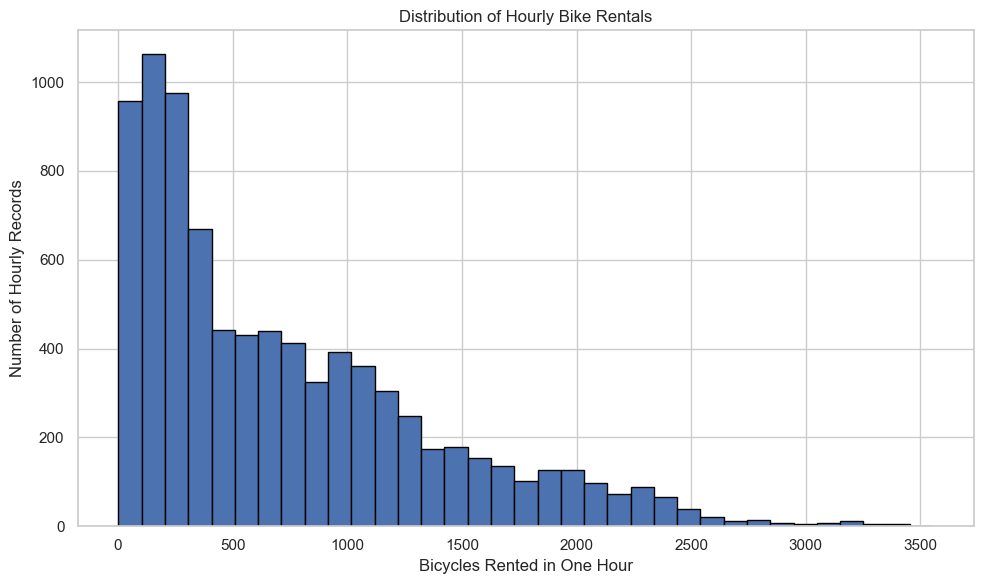

In [6]:
plt.figure(figsize=(10, 6))                                             # Creates a clear chart area.
plt.hist(
    df["rented_bike_count"],
    bins=35,
    edgecolor="black",
)                                                                       # Groups hourly demand values into easy-to-read ranges.
plt.title("Distribution of Hourly Bike Rentals")                        # Explains what the chart shows.
plt.xlabel("Bicycles Rented in One Hour")                               # Labels the horizontal demand scale.
plt.ylabel("Number of Hourly Records")                                  # Labels how many records fall in each range.
plt.tight_layout()                                                       # Prevents labels from being cut off.
plt.show()                                                               # Displays the finished chart.

### 6.2 Average bike demand by hour

This line chart shows the average number of bicycles rented at each hour of the day. Peaks usually represent busy travelling periods, while low points normally represent quiet late-night hours.

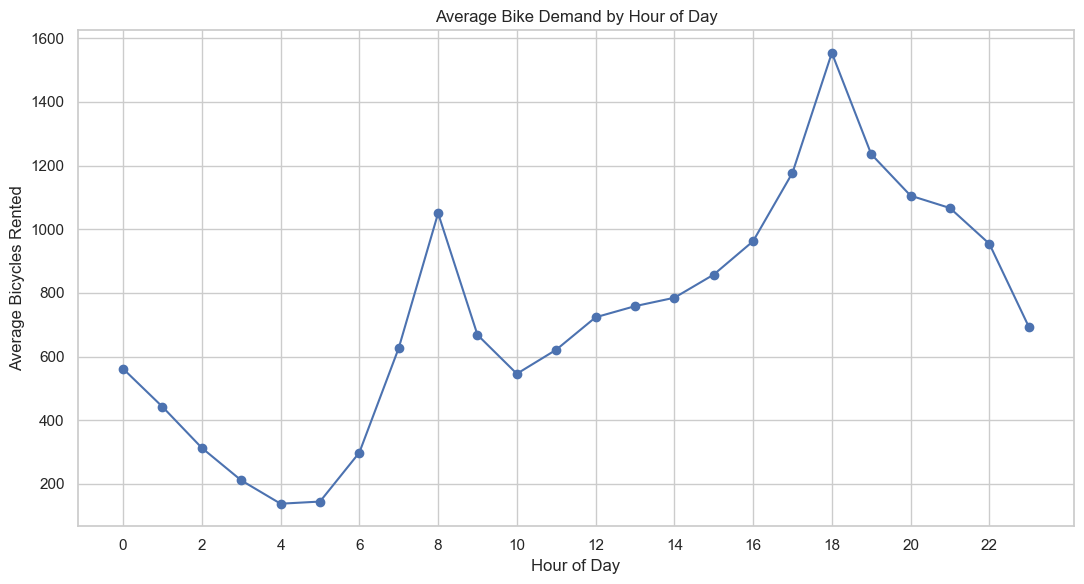

In [7]:
hourly_demand = (
    df.groupby("hour", as_index=False)["rented_bike_count"]
    .mean()
)                                                                       # Calculates the average demand for every hour.

plt.figure(figsize=(11, 6))                                             # Uses a wide layout for the full 24-hour period.
plt.plot(
    hourly_demand["hour"],
    hourly_demand["rented_bike_count"],
    marker="o",
)                                                                       # Connects average demand values from hour 0 to hour 23.
plt.title("Average Bike Demand by Hour of Day")                          # Gives the chart a clear title.
plt.xlabel("Hour of Day")                                               # Shows when the demand happened.
plt.ylabel("Average Bicycles Rented")                                   # Shows the average rental count.
plt.xticks(range(0, 24, 2))                                             # Displays every second hour for easier reading.
plt.tight_layout()                                                       # Keeps all labels inside the figure.
plt.show()                                                               # Displays the chart.

### 6.3 Average bike demand by season

This bar chart compares the average hourly demand in Winter, Spring, Summer, and Autumn. Taller bars represent seasons with stronger average rental activity.

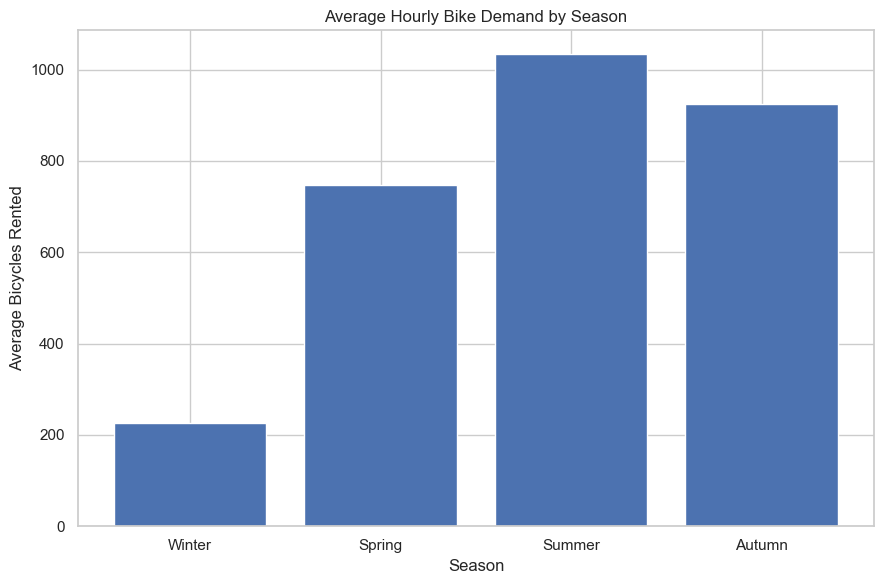

In [8]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]                 # Places seasons in a natural yearly order.

seasonal_demand = (
    df.groupby("season")["rented_bike_count"]
    .mean()
    .reindex(season_order)
)                                                                       # Calculates and orders the average demand by season.

plt.figure(figsize=(9, 6))                                              # Creates enough space for four season bars.
plt.bar(
    seasonal_demand.index,
    seasonal_demand.values,
)                                                                       # Draws one average-demand bar for each season.
plt.title("Average Hourly Bike Demand by Season")                       # Explains the comparison.
plt.xlabel("Season")                                                    # Labels the seasonal categories.
plt.ylabel("Average Bicycles Rented")                                   # Labels the average rental count.
plt.tight_layout()                                                       # Prevents labels from overlapping.
plt.show()                                                               # Displays the chart.

### 6.4 Demand spread by season

This box plot compares the middle demand, common demand range, and overall spread for every season. The line inside each box is the median, while a taller box means the demand changes more widely.

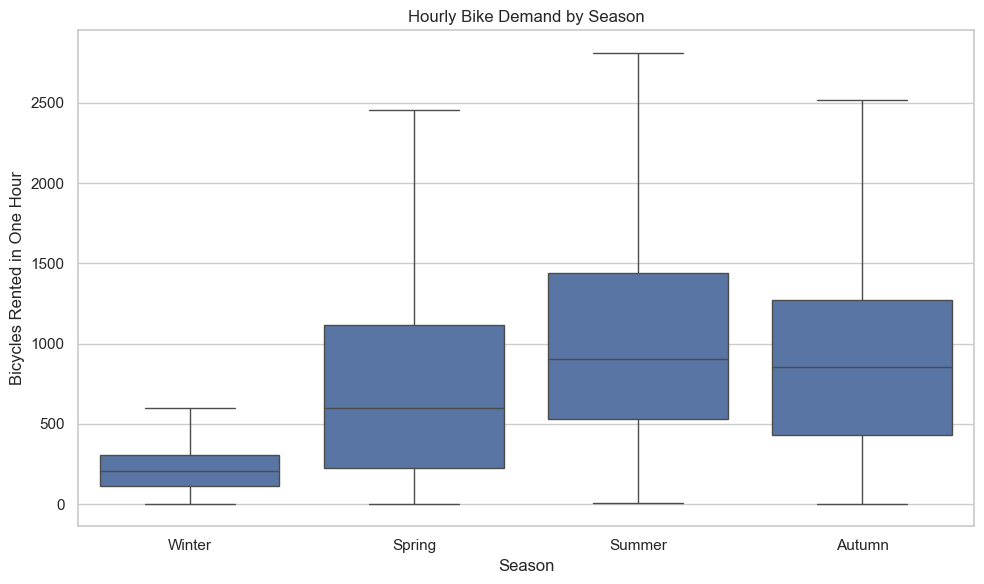

In [9]:
plt.figure(figsize=(10, 6))                                             # Creates a clear comparison area.
sns.boxplot(
    data=df,
    x="season",
    y="rented_bike_count",
    order=season_order,
    showfliers=False,
)                                                                       # Compares the main demand spread without extreme dots.
plt.title("Hourly Bike Demand by Season")                               # Gives the chart a simple title.
plt.xlabel("Season")                                                    # Labels the four categories.
plt.ylabel("Bicycles Rented in One Hour")                               # Labels the hourly demand values.
plt.tight_layout()                                                       # Keeps all text visible.
plt.show()                                                               # Displays the chart.

### 6.5 Temperature and bike demand

This scatter plot shows whether warmer or colder conditions are linked with different rental levels. Each point represents one operating hour.

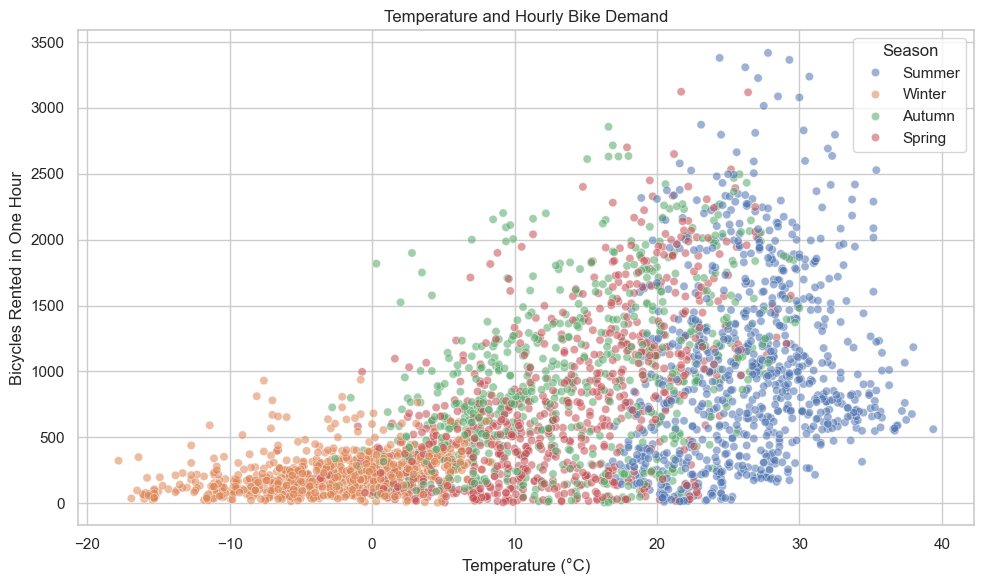

In [10]:
sample_df = df.sample(
    min(3000, len(df)),
    random_state=RANDOM_STATE,
)                                                                       # Uses a manageable sample so points remain readable.

plt.figure(figsize=(10, 6))                                             # Creates a clear chart area.
sns.scatterplot(
    data=sample_df,
    x="temperature_c",
    y="rented_bike_count",
    hue="season",
    alpha=0.55,
)                                                                       # Plots hourly demand against temperature and season.
plt.title("Temperature and Hourly Bike Demand")                         # Explains the relationship being studied.
plt.xlabel("Temperature (°C)")                                         # Shows the weather measurement.
plt.ylabel("Bicycles Rented in One Hour")                               # Shows the hourly demand value.
plt.legend(title="Season")                                             # Explains the season colours.
plt.tight_layout()                                                       # Keeps labels and legend inside the chart.
plt.show()                                                               # Displays the chart.

### 6.6 Correlation heatmap

This heatmap shows the direction and strength of linear relationships between numerical variables. Values closer to 1 indicate a positive relationship, values closer to -1 indicate a negative relationship, and values near 0 indicate a weak linear relationship.

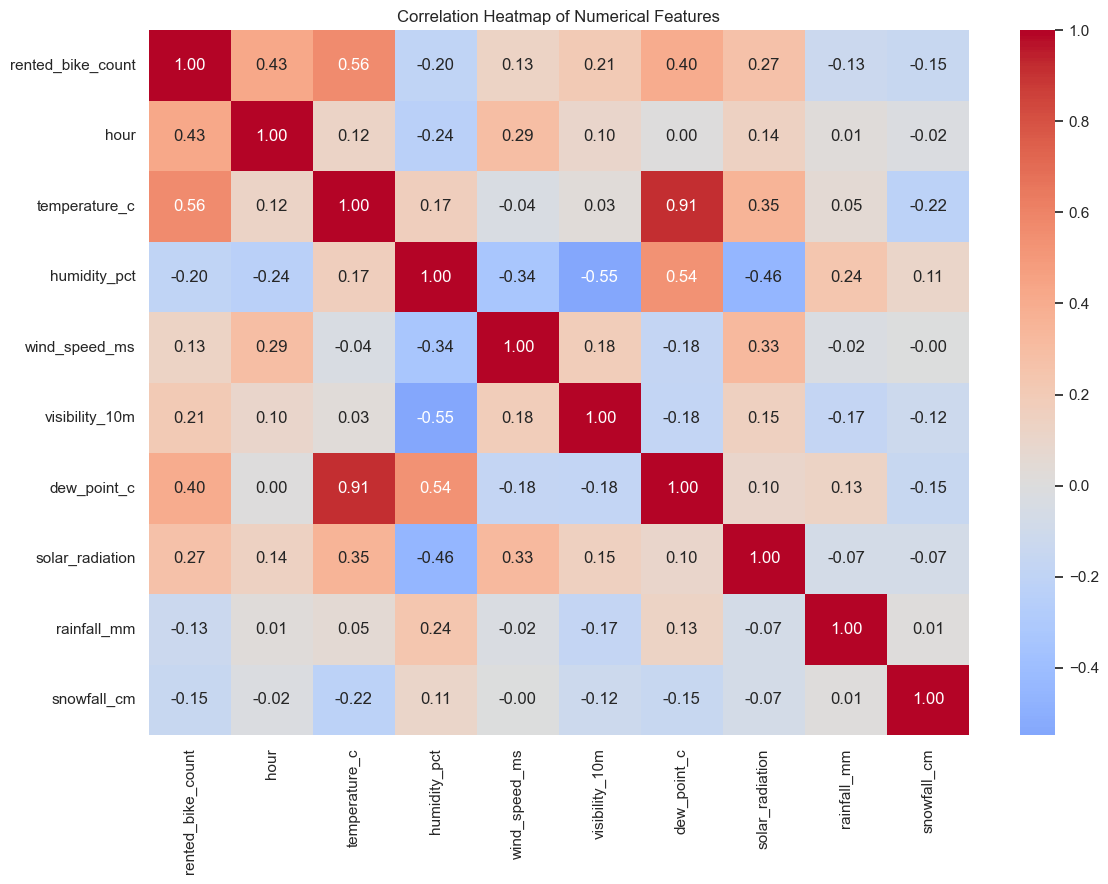

In [11]:
correlation_columns = [
    "rented_bike_count",
    "hour",
    "temperature_c",
    "humidity_pct",
    "wind_speed_ms",
    "visibility_10m",
    "dew_point_c",
    "solar_radiation",
    "rainfall_mm",
    "snowfall_cm",
]

correlation_matrix = df[correlation_columns].corr()                     # Calculates all numerical pair relationships.

plt.figure(figsize=(12, 9))                                             # Makes the heatmap large enough to read.
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)                                                                       # Displays each correlation using a number and colour.
plt.title("Correlation Heatmap of Numerical Features")                  # Gives the chart a clear title.
plt.tight_layout()                                                       # Keeps all labels visible.
plt.show()                                                               # Displays the heatmap.

### 6.7 Average demand during rain and no-rain periods

The previous violin chart was removed because it was harder to interpret. This grouped bar chart gives a simpler comparison. The height of each bar shows the average number of bicycles rented during rainy and non-rainy hours.

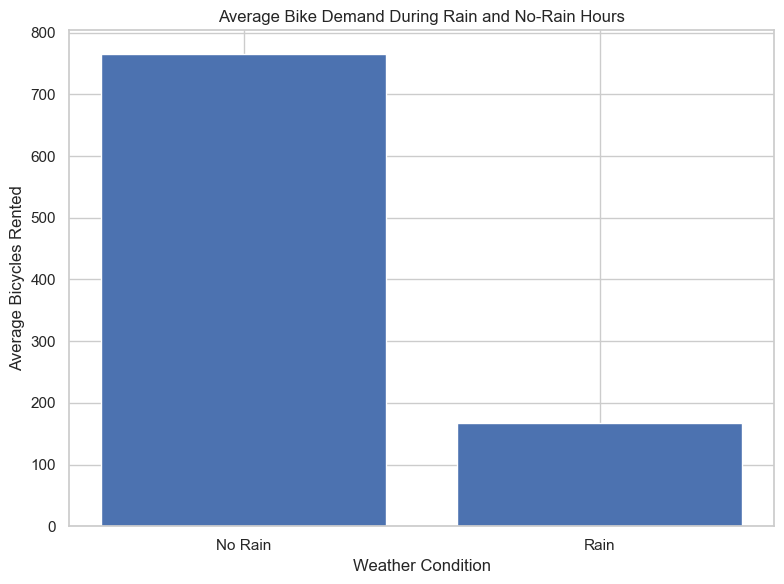

In [12]:
rain_comparison = df.copy()                                              # Creates a separate copy for the rain comparison.
rain_comparison["rain_condition"] = np.where(
    rain_comparison["rainfall_mm"] > 0,
    "Rain",
    "No Rain",
)                                                                       # Divides the records into two clear weather groups.

rain_summary = (
    rain_comparison.groupby("rain_condition", as_index=False)["rented_bike_count"]
    .mean()
)                                                                       # Calculates the average demand for both groups.

plt.figure(figsize=(8, 6))                                              # Creates a simple two-bar chart.
plt.bar(
    rain_summary["rain_condition"],
    rain_summary["rented_bike_count"],
)                                                                       # Compares average demand during rain and no rain.
plt.title("Average Bike Demand During Rain and No-Rain Hours")          # States the purpose of the chart.
plt.xlabel("Weather Condition")                                        # Labels the two comparison groups.
plt.ylabel("Average Bicycles Rented")                                   # Labels the average demand value.
plt.tight_layout()                                                       # Keeps all labels visible.
plt.show()                                                               # Displays the easier replacement chart.

## 7. Feature engineering

Feature engineering creates new useful information from existing columns. The project creates four derived features: peak-hour status, a simple weather comfort index, and two circular hour features.

In [13]:
df["peak_hour"] = df["hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)                                                            # Marks common morning and evening travel periods.

df["comfort_index"] = (
    df["temperature_c"] - (0.05 * df["humidity_pct"])
)                                                                       # Combines temperature and humidity into one comfort signal.

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)                                                                       # Represents the hour as part of a repeating daily cycle.

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)                                                                       # Works with hour_sin to keep midnight close to late night.

display(
    df[
        [
            "hour",
            "temperature_c",
            "humidity_pct",
            "peak_hour",
            "comfort_index",
            "hour_sin",
            "hour_cos",
        ]
    ].head().round(3)
)                                                                       # Shows the newly created features.

,hour,temperature_c,humidity_pct,peak_hour,comfort_index,hour_sin,hour_cos
0,0,-5.2,37,0,-7.05,0.000,1.000
1,1,-5.5,38,0,-7.40,0.259,0.966
2,2,-6.0,39,0,-7.95,0.500,0.866
3,3,-6.2,40,0,-8.20,0.707,0.707
4,4,-6.0,36,0,-7.80,0.866,0.500


## 8. Feature selection

Feature selection identifies which columns contribute useful predictive information. A wider candidate set is tested using permutation importance. The final user-facing features are chosen based on predictive value, practical meaning, and ease of use.

In [14]:
candidate_features = [
    "hour",
    "temperature_c",
    "humidity_pct",
    "wind_speed_ms",
    "visibility_10m",
    "solar_radiation",
    "rainfall_mm",
    "snowfall_cm",
    "season",
    "holiday",
    "peak_hour",
    "comfort_index",
    "hour_sin",
    "hour_cos",
]

candidate_categorical = ["season", "holiday"]                           # Lists text-based features that need encoding.
candidate_numeric = [
    feature for feature in candidate_features
    if feature not in candidate_categorical
]                                                                       # Keeps the remaining numerical features.

selection_preprocessor = ColumnTransformer([
    ("numeric", "passthrough", candidate_numeric),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        candidate_categorical,
    ),
])                                                                      # Prepares both numerical and categorical inputs.

selection_model = Pipeline([
    ("preprocessor", selection_preprocessor),
    (
        "model",
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])                                                                      # Builds a tree model for feature-selection evidence.

X_candidates = df[candidate_features]                                   # Stores all possible predictor columns.
y_candidates = df["rented_bike_count"]                                 # Stores the rental-count target.

X_select_train, X_select_test, y_select_train, y_select_test = train_test_split(
    X_candidates,
    y_candidates,
    test_size=0.20,
    random_state=RANDOM_STATE,
)                                                                       # Creates an 80/20 split for feature selection.

selection_model.fit(
    X_select_train,
    y_select_train,
)                                                                       # Trains the selection model on the training portion.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['hour','temperature_c','humidity_pct',...,'comfort_index','hour_sin', 'hour_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [15]:
selection_importance = permutation_importance(
    selection_model,
    X_select_test,
    y_select_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1,
)                                                                       # Measures how much accuracy falls when each feature is shuffled.

selection_table = pd.DataFrame({
    "Feature": candidate_features,
    "Importance Mean": selection_importance.importances_mean,
    "Importance SD": selection_importance.importances_std,
}).sort_values(
    "Importance Mean",
    ascending=False,
)                                                                       # Arranges the strongest features at the top.

display(selection_table.round(4))                                       # Shows the feature-selection evidence.

,Feature,Importance Mean,Importance SD
12,hour_sin,0.1683,0.0074
11,comfort_index,0.1643,0.0078
8,season,0.1347,0.0070
0,hour,0.1091,0.0076
2,humidity_pct,0.1018,0.0047
1,temperature_c,0.0675,0.0043
5,solar_radiation,0.0507,0.0043
10,peak_hour,0.0485,0.0064
6,rainfall_mm,0.0319,0.0043
13,hour_cos,0.0282,0.0036


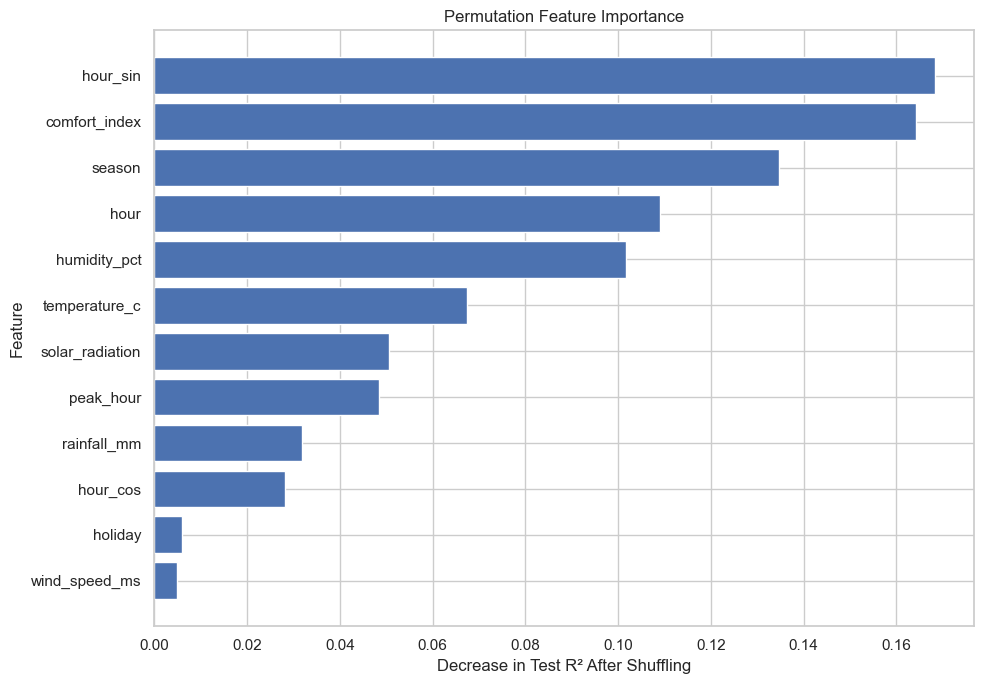

In [16]:
top_features = selection_table.head(12).sort_values("Importance Mean")  # Keeps the strongest features for the chart.

plt.figure(figsize=(10, 7))                                             # Creates enough room for feature names.
plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"],
)                                                                       # Draws one importance bar for each selected feature.
plt.title("Permutation Feature Importance")                             # Names the feature-selection method.
plt.xlabel("Decrease in Test R² After Shuffling")                       # Explains what a larger bar means.
plt.ylabel("Feature")                                                   # Labels the feature names.
plt.tight_layout()                                                       # Prevents labels from being cut off.
plt.show()                                                               # Displays the feature-importance chart.

## 9. Final modelling dataset

The final dashboard uses six clear inputs: hour, temperature, humidity, solar radiation, rainfall, and season. Four derived features are then calculated automatically. The target remains rented bike count.

In [17]:
MANUAL_FEATURES = [
    "hour",
    "temperature_c",
    "humidity_pct",
    "solar_radiation",
    "rainfall_mm",
    "season",
]                                                                       # Lists the inputs that the dashboard user controls.

DERIVED_FEATURES = [
    "peak_hour",
    "comfort_index",
    "hour_sin",
    "hour_cos",
]                                                                       # Lists the features calculated automatically.

MODEL_FEATURES = MANUAL_FEATURES + DERIVED_FEATURES                     # Combines manual and derived predictors.
TARGET = "rented_bike_count"                                           # Defines the value that the model must predict.

X = df[MODEL_FEATURES].copy()                                           # Stores the final predictor columns.
y = df[TARGET].copy()                                                   # Stores the target column.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)                                                                       # Uses 80% for training and 20% for final testing.

print("Training rows:", len(X_train))                                   # Shows how many records train the models.
print("Testing rows:", len(X_test))                                     # Shows how many unseen records test the models.

Training rows: 6772
Testing rows: 1693


## 10. Data preprocessing

Ridge Regression needs numerical scaling, while tree-based models do not. Season is categorical, so one-hot encoding converts it into machine-readable columns.

In [18]:
categorical_features = ["season"]                                      # Identifies the text-based final feature.
numeric_features = [
    feature for feature in MODEL_FEATURES
    if feature not in categorical_features
]                                                                       # Keeps all remaining numerical features.

linear_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        categorical_features,
    ),
])                                                                      # Scales numbers and encodes season for Ridge Regression.

tree_preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_features),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        categorical_features,
    ),
])                                                                      # Keeps numbers unchanged and encodes season for tree models.

## 11. Model training and comparison

Three regression models are trained using the same training data: Ridge Regression, Random Forest, and Extra Trees. Using the same split makes the comparison fair.

In [19]:
models = {
    "Ridge Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=350,
                max_features=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", tree_preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=450,
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
}                                                                       # Stores all models in one organised dictionary.

def calculate_regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }                                                                   # Calculates the three required regression metrics.

model_results = []                                                      # Stores evaluation results for each model.
fitted_models = {}                                                      # Stores each trained model for later use.

for model_name, model in models.items():
    model.fit(X_train, y_train)                                         # Trains the current model on the training data.
    predictions = model.predict(X_test)                                 # Predicts demand for the unseen test data.
    scores = calculate_regression_metrics(y_test, predictions)          # Calculates MAE, RMSE, and R².

    model_results.append({
        "Model": model_name,
        **scores,
    })                                                                  # Adds the current model results to the comparison.

    fitted_models[model_name] = model                                   # Saves the trained model in memory.

results_df = pd.DataFrame(model_results).sort_values("RMSE")            # Ranks models from lowest to highest RMSE.
display(results_df.round(3))                                            # Shows the model comparison table.

,Model,MAE,RMSE,R2
1,Random Forest,144.562,233.899,0.861
2,Extra Trees,146.892,237.268,0.857
0,Ridge Regression,293.305,387.707,0.617


## 12. Hyperparameter tuning with GridSearchCV

GridSearchCV tests several Extra Trees settings using cross-validation. This bonus step searches for a stronger model without using the final test set during tuning.

In [20]:
extra_trees_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        ExtraTreesRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])                                                                      # Creates the Extra Trees tuning pipeline.

parameter_grid = {
    "model__n_estimators": [350, 550],
    "model__max_features": [0.8, 1.0],
    "model__min_samples_leaf": [1, 2],
    "model__max_depth": [None, 24],
}                                                                       # Lists the parameter combinations to test.

grid_search = GridSearchCV(
    extra_trees_pipeline,
    parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    n_jobs=-1,
)                                                                       # Uses five-fold cross-validation during tuning.

grid_search.fit(X_train, y_train)                                       # Searches for the best Extra Trees settings.

best_extra_trees = grid_search.best_estimator_                          # Stores the strongest tuned pipeline.
best_extra_predictions = best_extra_trees.predict(X_test)               # Tests the tuned model on unseen records.
best_extra_scores = calculate_regression_metrics(
    y_test,
    best_extra_predictions,
)                                                                       # Calculates final test metrics for the tuned model.

print("Best parameters:", grid_search.best_params_)                     # Shows the winning parameter settings.
print("Cross-validation RMSE:", round(-grid_search.best_score_, 3))     # Shows the average tuning performance.
print("Test metrics:", {k: round(v, 3) for k, v in best_extra_scores.items()})

Best parameters: {'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__n_estimators': 550}
Cross-validation RMSE: 243.139
Test metrics: {'MAE': 146.152, 'RMSE': 232.113, 'R2': 0.863}


## 13. Final model comparison and selection

The tuned model is added to the comparison. The best model is selected using the lowest test RMSE. MAE and R² are also reviewed to make sure the result is balanced.

In [21]:
final_results = pd.concat([
    results_df,
    pd.DataFrame([
        {
            "Model": "Tuned Extra Trees",
            **best_extra_scores,
        }
    ]),
], ignore_index=True).sort_values("RMSE")                               # Adds the tuned model to the earlier comparison.

display(final_results.round(3))                                         # Displays the complete final comparison.

best_model_name = final_results.iloc[0]["Model"]                        # Reads the name of the model with the lowest RMSE.

if best_model_name == "Tuned Extra Trees":
    best_model = best_extra_trees                                       # Uses the tuned model if it ranks first.
elif best_model_name in fitted_models:
    best_model = fitted_models[best_model_name]                         # Otherwise uses the best original trained model.
else:
    raise ValueError("The selected model could not be found.")          # Stops if the model name is unexpected.

print("Selected final model:", best_model_name)                         # Confirms which model will be saved.

,Model,MAE,RMSE,R2
3,Tuned Extra Trees,146.152,232.113,0.863
0,Random Forest,144.562,233.899,0.861
1,Extra Trees,146.892,237.268,0.857
2,Ridge Regression,293.305,387.707,0.617


Selected final model: Tuned Extra Trees


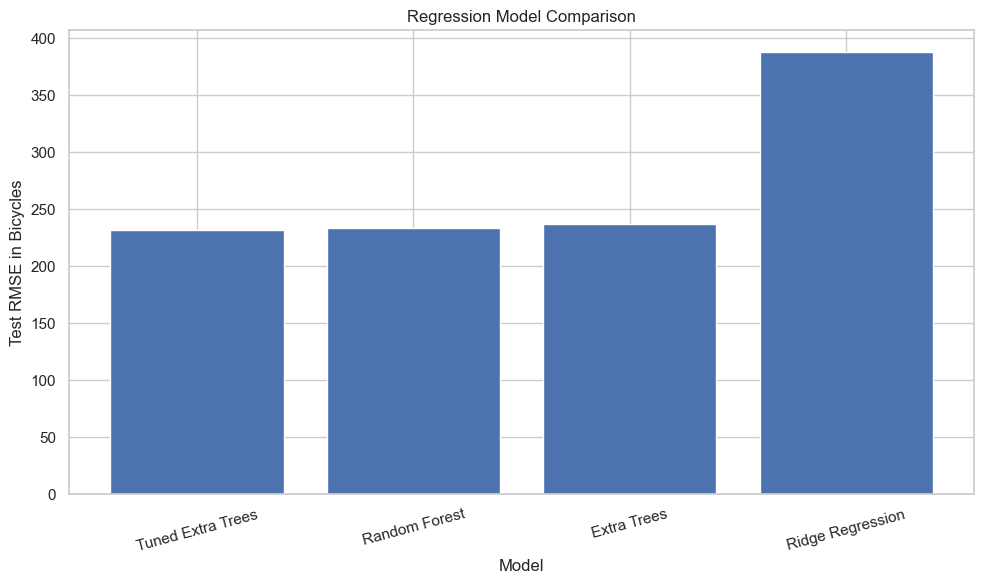

In [22]:
plt.figure(figsize=(10, 6))                                             # Creates a clear model-comparison chart.
plt.bar(
    final_results["Model"],
    final_results["RMSE"],
)                                                                       # Compares model error using one bar per model.
plt.title("Regression Model Comparison")                                # Gives the chart a clear title.
plt.xlabel("Model")                                                     # Labels the compared algorithms.
plt.ylabel("Test RMSE in Bicycles")                                     # Shows that lower values are better.
plt.xticks(rotation=15)                                                 # Tilts long model names for readability.
plt.tight_layout()                                                       # Keeps all labels visible.
plt.show()                                                               # Displays the model-comparison chart.

## 14. Final model evaluation

The selected model is evaluated using actual-versus-predicted values and residuals. A prediction close to the diagonal line is more accurate. Residuals near zero indicate smaller errors.

In [23]:
final_predictions = best_model.predict(X_test)                          # Creates predictions using the selected final model.

prediction_results = pd.DataFrame({
    "Actual Demand": y_test.values,
    "Predicted Demand": final_predictions,
})                                                                      # Places actual and predicted values side by side.

prediction_results["Absolute Error"] = (
    prediction_results["Actual Demand"] -
    prediction_results["Predicted Demand"]
).abs()                                                                 # Calculates the size of each prediction mistake.

display(prediction_results.head(15).round(1))                           # Shows several individual prediction examples.

,Actual Demand,Predicted Demand,Absolute Error
0,1232,1258.8,26.8
1,964,875.6,88.4
2,942,1122.8,180.8
3,373,328.5,44.5
4,1259,1847.6,588.6
5,476,607.3,131.3
6,1062,1073.6,11.6
7,253,254.2,1.2
8,2857,2133.4,723.6
9,1039,1039.8,0.8


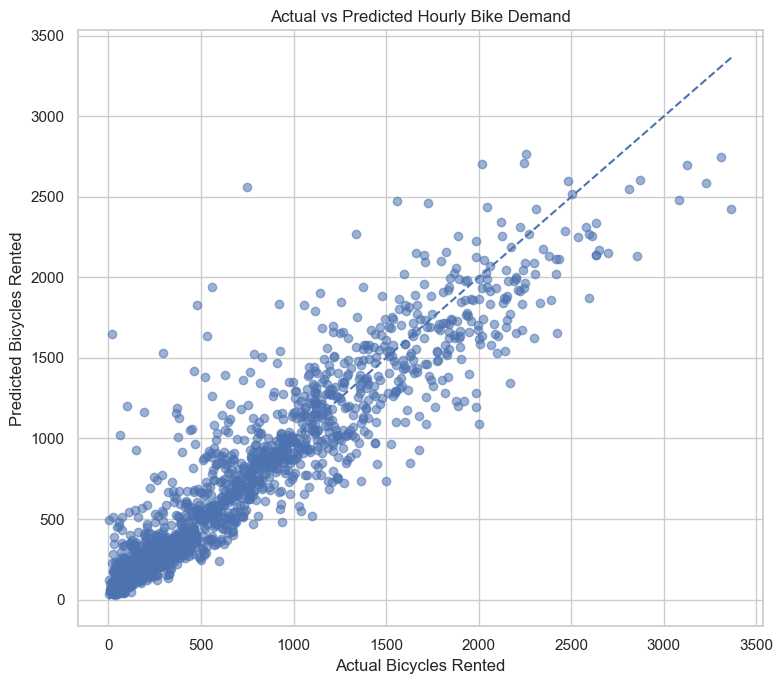

In [24]:
plt.figure(figsize=(8, 7))                                              # Creates a square comparison chart.
plt.scatter(
    prediction_results["Actual Demand"],
    prediction_results["Predicted Demand"],
    alpha=0.55,
)                                                                       # Plots actual demand against predicted demand.

minimum_value = min(
    prediction_results["Actual Demand"].min(),
    prediction_results["Predicted Demand"].min(),
)                                                                       # Finds the lowest value for the reference line.

maximum_value = max(
    prediction_results["Actual Demand"].max(),
    prediction_results["Predicted Demand"].max(),
)                                                                       # Finds the highest value for the reference line.

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)                                                                       # Adds the perfect-prediction diagonal line.

plt.title("Actual vs Predicted Hourly Bike Demand")                     # Explains the comparison.
plt.xlabel("Actual Bicycles Rented")                                    # Labels the real values.
plt.ylabel("Predicted Bicycles Rented")                                 # Labels the model estimates.
plt.tight_layout()                                                       # Keeps all labels visible.
plt.show()                                                               # Displays the chart.

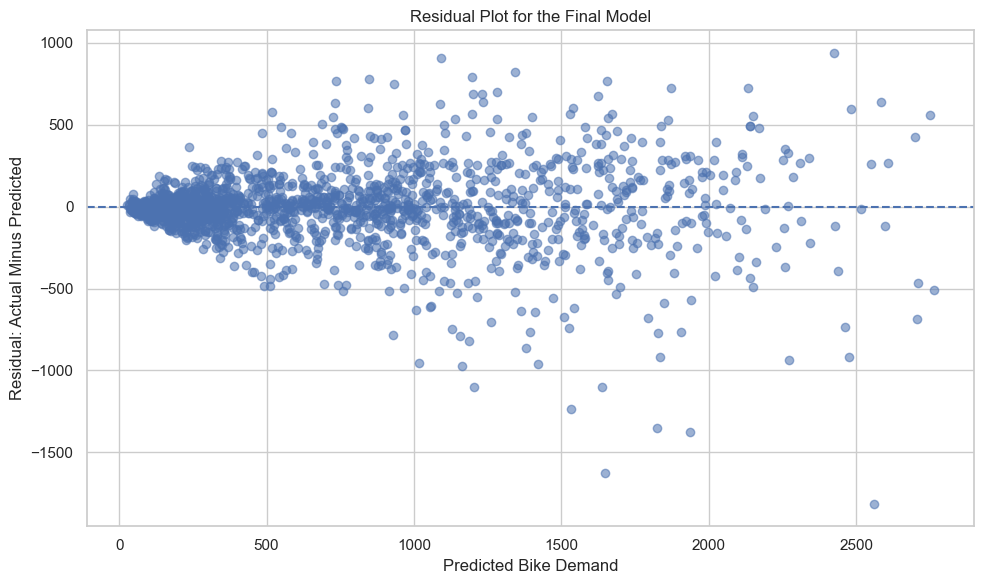

In [25]:
residuals = (
    prediction_results["Actual Demand"] -
    prediction_results["Predicted Demand"]
)                                                                       # Calculates actual value minus predicted value.

plt.figure(figsize=(10, 6))                                             # Creates a residual-analysis chart.
plt.scatter(
    prediction_results["Predicted Demand"],
    residuals,
    alpha=0.55,
)                                                                       # Shows model errors across different prediction levels.
plt.axhline(
    0,
    linestyle="--",
)                                                                       # Adds a zero-error reference line.
plt.title("Residual Plot for the Final Model")                          # Gives the chart a clear title.
plt.xlabel("Predicted Bike Demand")                                     # Labels the prediction values.
plt.ylabel("Residual: Actual Minus Predicted")                          # Explains the error direction.
plt.tight_layout()                                                       # Keeps all labels visible.
plt.show()                                                               # Displays the residual plot.

## 15. Final feature importance

Permutation importance is calculated again using the selected final model and the final feature set. A larger bar means the model depends more strongly on that feature.

In [26]:
final_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=12,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)                                                                       # Measures each final feature's effect on prediction error.

final_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": final_importance.importances_mean,
    "Importance SD": final_importance.importances_std,
}).sort_values(
    "Importance Mean",
    ascending=False,
)                                                                       # Arranges the most important features first.

display(final_importance_df.round(3))                                   # Shows the final importance table.

,Feature,Importance Mean,Importance SD
7,comfort_index,112.634,4.543
8,hour_sin,109.516,4.294
5,season,102.777,4.246
0,hour,85.189,4.145
2,humidity_pct,78.748,4.749
1,temperature_c,53.008,2.709
6,peak_hour,40.512,3.209
3,solar_radiation,36.937,3.525
9,hour_cos,20.909,3.502
4,rainfall_mm,18.337,2.600


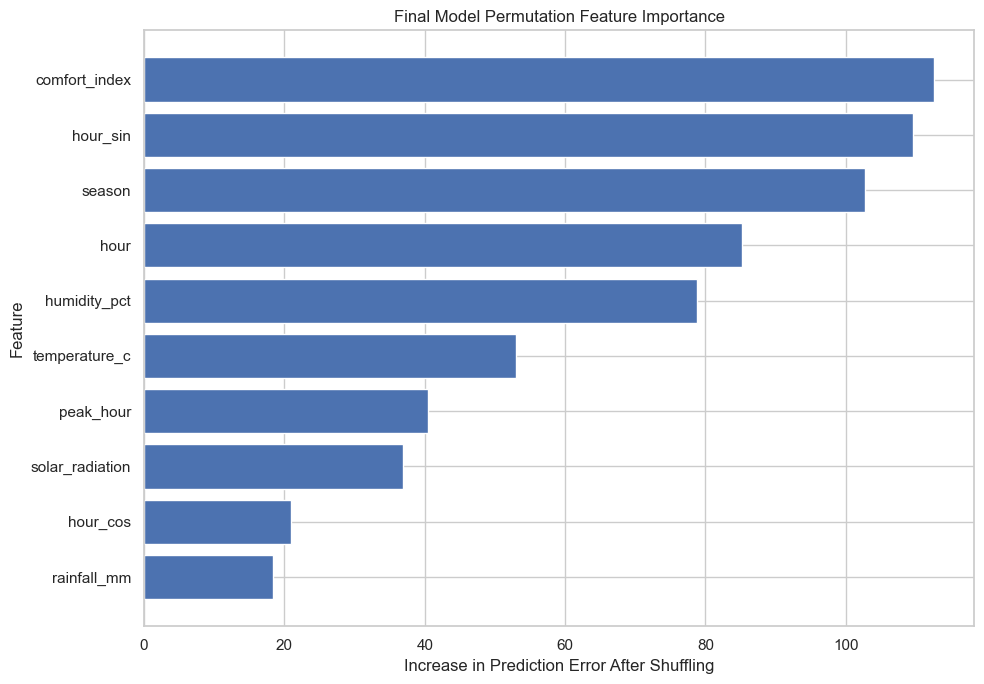

In [27]:
importance_chart = final_importance_df.sort_values("Importance Mean")   # Orders features from smallest to largest for plotting.

plt.figure(figsize=(10, 7))                                             # Creates enough room for all feature names.
plt.barh(
    importance_chart["Feature"],
    importance_chart["Importance Mean"],
)                                                                       # Draws one importance bar for every final feature.
plt.title("Final Model Permutation Feature Importance")                 # Names the interpretation method.
plt.xlabel("Increase in Prediction Error After Shuffling")              # Explains the importance scale.
plt.ylabel("Feature")                                                   # Labels the model inputs.
plt.tight_layout()                                                       # Prevents feature names from being cut off.
plt.show()                                                               # Displays the importance chart.

## 16. Save project outputs

This section saves the model, model results, and feature-importance results. These files are used by the Streamlit dashboard and GitHub repository.

In [28]:
final_results.to_csv(
    "model_results.csv",
    index=False,
)                                                                       # Saves the model comparison results.

final_importance_df.to_csv(
    "feature_importance.csv",
    index=False,
)                                                                       # Saves the final feature-importance results.

manual_ranges = {
    feature: {
        "min": float(df[feature].min()),
        "max": float(df[feature].max()),
        "median": float(df[feature].median()),
    }
    for feature in [
        "hour",
        "temperature_c",
        "humidity_pct",
        "solar_radiation",
        "rainfall_mm",
    ]
}                                                                       # Stores safe dashboard ranges from the real dataset.

final_scores = calculate_regression_metrics(
    y_test,
    final_predictions,
)                                                                       # Calculates the selected model's final test metrics.

model_bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "manual_features": MANUAL_FEATURES,
    "model_features": MODEL_FEATURES,
    "target": TARGET,
    "seasons": sorted(df["season"].dropna().unique().tolist()),
    "manual_ranges": manual_ranges,
    "metrics": final_scores,
    "training_rows": len(X_train),
    "testing_rows": len(X_test),
    "functioning_days_only": True,
}                                                                       # Packages everything needed by the Streamlit dashboard.

joblib.dump(
    model_bundle,
    "WheelWise_Predictor.joblib",
)                                                                       # Saves the complete deployment-ready model file.

print("Saved model: WheelWise_Predictor.joblib")                    # Confirms the model file was created.
print("Saved results: model_results.csv")                               # Confirms the comparison file was created.
print("Saved importance: feature_importance.csv")                       # Confirms the importance file was created.

Saved model: WheelWise_Predictor.joblib
Saved results: model_results.csv
Saved importance: feature_importance.csv
